# 02: Baseline Models
**Project:** Robust Financial Fraud Detection using GNNs and Multimodal Fusion
**Author:** Israt Islam | 23082056 | University of Hertfordshire
**Purpose:** Train four baseline classifiers using sample weights to achieve 48/52 class balance without synthetic data. Evaluate with AUC-ROC, F1, Precision, Recall, FPR, and learning curves.

---

## 1. Install Dependencies

In [1]:
# Install LightGBM which is not pre-installed in Google Colab
!pip install lightgbm -q
print('Installation complete.')

Installation complete.


## 2. Setup and Load Data
Mount Drive, import libraries, load preprocessed splits from NB01, and clean infinite values.

In [2]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FraudProject'

# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib       # for saving/loading sklearn models
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

def savefig(name):
    """
    Save current matplotlib figure to /figures/ at 300dpi (thesis quality).

    Args:
        name (str): Filename without extension
    """
    plt.savefig(f'{BASE}/figures/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> figures/{name}.png')

# ── Load preprocessed data from Notebook 01 ──────────────────────────────────
print('Loading data...')
X_train = pd.read_parquet(f'{BASE}/processed/X_train.parquet')
X_test  = pd.read_parquet(f'{BASE}/processed/X_test.parquet')
y_train = np.load(f'{BASE}/processed/y_train.npy')
y_test  = np.load(f'{BASE}/processed/y_test.npy')

# ── Clean infinite values created by amt_zscore (division by zero) ────────────
# When a card has only 1 transaction, std=0 causes inf values
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

print(f'X_train: {X_train.shape} | Fraud: {y_train.mean()*100:.2f}%')
print(f'X_test:  {X_test.shape}  | Fraud: {y_test.mean()*100:.2f}%')

Mounted at /content/drive
Loading data...
X_train: (472432, 365) | Fraud: 3.51%
X_test:  (118108, 365)  | Fraud: 3.44%


## 3. Sample Weights (48/52 Balance)
Assign weights so fraud = 48% and legitimate = 52% of training signal. No synthetic data — uses only real transactions.

Sample Weight Calculation
  Fraud samples:           16,599 (3.5% of data)
  Legit samples:           455,833 (96.5% of data)
  Weight per fraud sample: 13.6615
  Weight per legit sample: 0.5389
  Effective fraud weight:  48.0% (target 48%)
  Effective legit weight:  52.0% (target 52%)
  No synthetic data used.


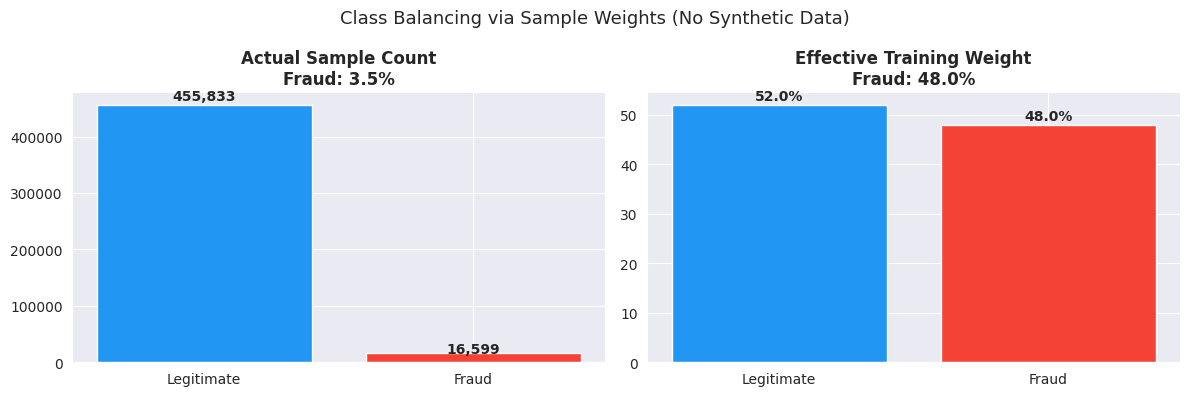

  Saved -> figures/07_class_weights.png


In [3]:
# ── Target class balance ratios ───────────────────────────────────────────────
TARGET_FRAUD = 0.48  # desired fraud weight proportion
TARGET_LEGIT = 0.52  # desired legitimate weight proportion

# ── Count samples per class ───────────────────────────────────────────────────
n_fraud = (y_train == 1).sum()
n_legit = (y_train == 0).sum()
n_total = len(y_train)

# ── Calculate per-sample weights ──────────────────────────────────────────────
# Formula: weight = (target_proportion / n_class) * n_total
# This ensures the weighted sum for each class equals the target proportion
w_fraud = (TARGET_FRAUD / n_fraud) * n_total
w_legit = (TARGET_LEGIT / n_legit) * n_total

# ── Create sample weight array (one weight per training sample) ───────────────
sample_weights = np.where(y_train == 1, w_fraud, w_legit)

# ── Verify effective balance ──────────────────────────────────────────────────
eff_fraud = sample_weights[y_train==1].sum() / sample_weights.sum() * 100
eff_legit = sample_weights[y_train==0].sum() / sample_weights.sum() * 100

print('Sample Weight Calculation')
print('='*45)
print(f'  Fraud samples:           {n_fraud:,} ({n_fraud/n_total*100:.1f}% of data)')
print(f'  Legit samples:           {n_legit:,} ({n_legit/n_total*100:.1f}% of data)')
print(f'  Weight per fraud sample: {w_fraud:.4f}')
print(f'  Weight per legit sample: {w_legit:.4f}')
print(f'  Effective fraud weight:  {eff_fraud:.1f}% (target 48%)')
print(f'  Effective legit weight:  {eff_legit:.1f}% (target 52%)')
print('  No synthetic data used.')

# ── Visualise class balance ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (vals, title) in zip(axes, [
    ([n_legit, n_fraud], f'Actual Sample Count\nFraud: {n_fraud/n_total*100:.1f}%'),
    ([eff_legit, eff_fraud], f'Effective Training Weight\nFraud: {eff_fraud:.1f}%')
]):
    bars = ax.bar(['Legitimate','Fraud'], vals, color=['#2196F3','#F44336'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:,.0f}' if v > 100 else f'{v:.1f}%', ha='center', fontweight='bold')
plt.suptitle('Class Balancing via Sample Weights (No Synthetic Data)', fontsize=13)
plt.tight_layout()
savefig('07_class_weights')

## 4. Evaluation Helper Function
A single consistent function to evaluate all models fairly on the same metrics.

In [4]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Evaluate a binary classification model on all fraud detection metrics.

    Args:
        name (str):          Model name for display
        y_true (np.array):   Ground truth labels (0=legit, 1=fraud)
        y_pred (np.array):   Predicted labels (0 or 1)
        y_prob (np.array):   Predicted probabilities for class 1 (fraud)

    Returns:
        dict: All computed metrics
    """
    # Compute confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # False Positive Rate = FP / (FP + TN)
    # Proportion of legitimate transactions incorrectly flagged as fraud
    fpr_val = fp / (fp + tn)

    metrics = {
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'FPR':       round(fpr_val, 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn)
    }

    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    for k in ['AUC-ROC','F1','Precision','Recall','FPR']:
        note = '  <- lower is better' if k=='FPR' else ''
        print(f'  {k:10} {metrics[k]}{note}')
    print(f'  TP:{tp}  FP:{fp}  TN:{tn}  FN:{fn}')
    return metrics

results = []  # collect all model results for comparison table
print('Evaluation function ready.')

Evaluation function ready.


## 5. Model 1: Logistic Regression
Simplest baseline. Assumes linear decision boundaries. Requires feature scaling. Serves as lower bound of performance.

In [5]:
print('Training Logistic Regression...')

# ── Scale features (required for Logistic Regression) ────────────────────────
# LR is sensitive to feature scale — StandardScaler normalises to mean=0, std=1
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)  # fit on train, transform train
X_te_sc  = scaler.transform(X_test)       # transform test using TRAIN statistics

# ── Train Logistic Regression with sample weights ─────────────────────────────
lr = LogisticRegression(
    max_iter=1000,    # increase iterations for convergence
    random_state=42,  # reproducibility
    n_jobs=-1         # use all CPU cores
)
lr.fit(X_tr_sc, y_train, sample_weight=sample_weights)

# ── Evaluate ──────────────────────────────────────────────────────────────────
lr_probs = lr.predict_proba(X_te_sc)[:, 1]  # probability of fraud
lr_preds = lr.predict(X_te_sc)              # predicted class (0 or 1)
results.append(evaluate_model('Logistic Regression', y_test, lr_preds, lr_probs))

# ── Save model and scaler ─────────────────────────────────────────────────────
joblib.dump(lr,     f'{BASE}/models/lr_model.pkl')
joblib.dump(scaler, f'{BASE}/models/scaler.pkl')
print('  Saved -> lr_model.pkl, scaler.pkl')

Training Logistic Regression...

  Logistic Regression
  AUC-ROC    0.8306
  F1         0.1703
  Precision  0.0959
  Recall     0.7625
  FPR        0.2563  <- lower is better
  TP:3099  FP:29228  TN:84816  FN:965
  Saved -> lr_model.pkl, scaler.pkl


## 6. Model 2: Random Forest
Ensemble of 200 decision trees. Handles non-linear relationships. Does not require feature scaling.

In [6]:
print('Training Random Forest (3-5 minutes)...')

# ── Train Random Forest with sample weights ───────────────────────────────────
# n_estimators=200: 200 trees in the forest
# max_depth=12: prevents overfitting by limiting tree depth
# n_jobs=-1: parallelise across all CPU cores
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=sample_weights)

# ── Evaluate ──────────────────────────────────────────────────────────────────
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, rf_preds, rf_probs))

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(rf, f'{BASE}/models/rf_model.pkl')
print('  Saved -> rf_model.pkl')

Training Random Forest (3-5 minutes)...

  Random Forest
  AUC-ROC    0.8715
  F1         0.3207
  Precision  0.2156
  Recall     0.6257
  FPR        0.0811  <- lower is better
  TP:2543  FP:9254  TN:104790  FN:1521
  Saved -> rf_model.pkl


## 7. Model 3: XGBoost with Learning Curves
Industry standard for tabular fraud detection. Sequential tree building where each tree corrects previous errors. We track learning curves to confirm no overfitting.

Training XGBoost with learning curves...
[0]	validation_0-logloss:0.63910	validation_0-auc:0.84783	validation_1-logloss:0.64007	validation_1-auc:0.82738
[100]	validation_0-logloss:0.32489	validation_0-auc:0.92377	validation_1-logloss:0.35951	validation_1-auc:0.89032
[200]	validation_0-logloss:0.27898	validation_0-auc:0.94734	validation_1-logloss:0.31417	validation_1-auc:0.90513
[300]	validation_0-logloss:0.25330	validation_0-auc:0.95936	validation_1-logloss:0.28664	validation_1-auc:0.90954
[400]	validation_0-logloss:0.23076	validation_0-auc:0.96841	validation_1-logloss:0.25999	validation_1-auc:0.91131
[472]	validation_0-logloss:0.21759	validation_0-auc:0.97321	validation_1-logloss:0.24763	validation_1-auc:0.91236

  XGBoost
  AUC-ROC    0.9127
  F1         0.3683
  Precision  0.2486
  Recall     0.7096
  FPR        0.0764  <- lower is better
  TP:2884  FP:8715  TN:105329  FN:1180
  Saved -> xgb_model.pkl


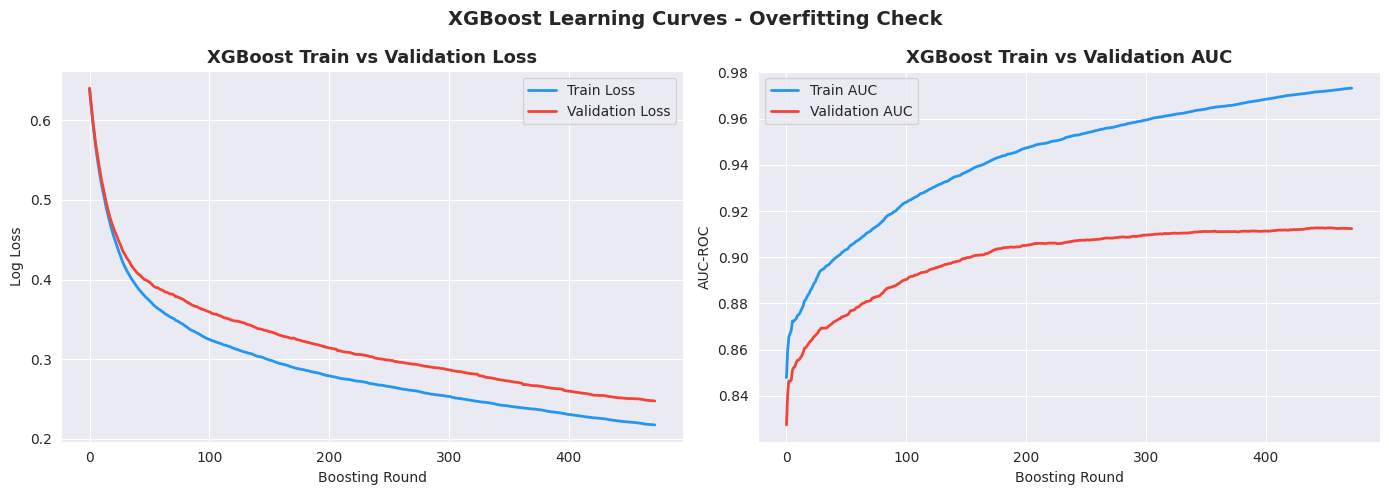

  Saved -> figures/10b_xgb_learning_curves.png


In [7]:
print('Training XGBoost with learning curves...')

# ── Train XGBoost ─────────────────────────────────────────────────────────────
# early_stopping_rounds=30: stop if no improvement after 30 rounds
# eval_metric: track both logloss and auc during training
# eval_set: provide validation set to monitor generalisation
xgb = XGBClassifier(
    n_estimators=500,       # max number of trees
    max_depth=6,            # tree depth (6 is standard for fraud)
    learning_rate=0.05,     # step size for each boosting round
    subsample=0.8,          # use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,   # use 80% of features per tree
    use_label_encoder=False,
    eval_metric=['logloss', 'auc'],  # track both metrics
    early_stopping_rounds=30,        # stop early if no improvement
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[
        (X_train, y_train),  # training performance
        (X_test,  y_test)    # validation performance
    ],
    verbose=100  # print progress every 100 rounds
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)
results.append(evaluate_model('XGBoost', y_test, xgb_preds, xgb_probs))

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(xgb, f'{BASE}/models/xgb_model.pkl')
print('  Saved -> xgb_model.pkl')

# ── Plot learning curves ──────────────────────────────────────────────────────
# Extract training history tracked by eval_set
evals_result = xgb.evals_result()
train_loss   = evals_result['validation_0']['logloss']
val_loss     = evals_result['validation_1']['logloss']
train_auc    = evals_result['validation_0']['auc']
val_auc      = evals_result['validation_1']['auc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve: train and validation should converge (not diverge)
axes[0].plot(train_loss, color='#2196F3', linewidth=2, label='Train Loss')
axes[0].plot(val_loss,   color='#F44336', linewidth=2, label='Validation Loss')
axes[0].set_title('XGBoost Train vs Validation Loss', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Log Loss')
axes[0].legend()

# AUC curve: validation AUC should climb and plateau (not drop)
axes[1].plot(train_auc, color='#2196F3', linewidth=2, label='Train AUC')
axes[1].plot(val_auc,   color='#F44336', linewidth=2, label='Validation AUC')
axes[1].set_title('XGBoost Train vs Validation AUC', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

plt.suptitle('XGBoost Learning Curves - Overfitting Check', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('10b_xgb_learning_curves')

## 8. Model 4: LightGBM with Learning Curves
Microsoft's faster alternative to XGBoost. Leaf-wise tree growth. Included to confirm XGBoost results across two independent implementations.

Training LightGBM with learning curves...

  LightGBM
  AUC-ROC    0.9099
  F1         0.3506
  Precision  0.2321
  Recall     0.716
  FPR        0.0844  <- lower is better
  TP:2910  FP:9626  TN:104418  FN:1154
  Saved -> lgbm_model.pkl


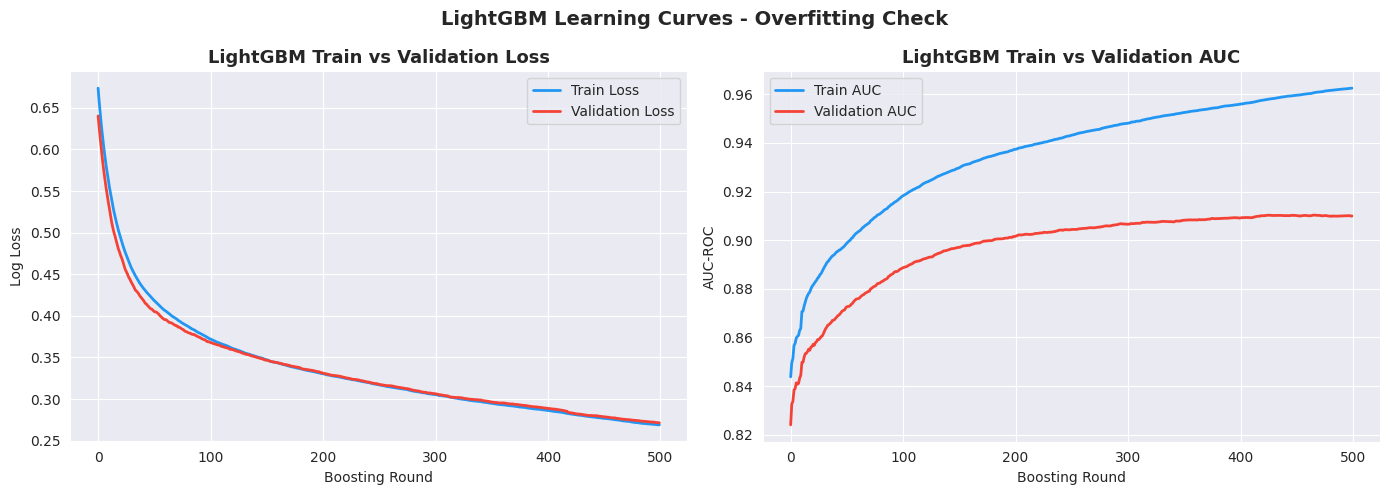

  Saved -> figures/10c_lgbm_learning_curves.png


In [8]:
print('Training LightGBM with learning curves...')
from lightgbm import record_evaluation

# ── Dictionary to store training history ─────────────────────────────────────
lgbm_evals = {}

# ── Train LightGBM ───────────────────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # suppress LightGBM output
)
lgbm.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[
        (X_train, y_train),  # track training performance
        (X_test,  y_test)    # track validation performance
    ],
    eval_metric=['binary_logloss', 'auc'],
    eval_names=['train', 'validation'],
    callbacks=[record_evaluation(lgbm_evals)]  # capture training history
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]
lgbm_preds = lgbm.predict(X_test)
results.append(evaluate_model('LightGBM', y_test, lgbm_preds, lgbm_probs))

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(lgbm, f'{BASE}/models/lgbm_model.pkl')
print('  Saved -> lgbm_model.pkl')

# ── Plot learning curves ──────────────────────────────────────────────────────
train_loss = lgbm_evals['train']['binary_logloss']
val_loss   = lgbm_evals['validation']['binary_logloss']
train_auc  = lgbm_evals['train']['auc']
val_auc    = lgbm_evals['validation']['auc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_loss, color='#2196F3', linewidth=2, label='Train Loss')
axes[0].plot(val_loss,   color='#F44336', linewidth=2, label='Validation Loss')
axes[0].set_title('LightGBM Train vs Validation Loss', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('Log Loss')
axes[0].legend()

axes[1].plot(train_auc, color='#2196F3', linewidth=2, label='Train AUC')
axes[1].plot(val_auc,   color='#F44336', linewidth=2, label='Validation AUC')
axes[1].set_title('LightGBM Train vs Validation AUC', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

plt.suptitle('LightGBM Learning Curves - Overfitting Check', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('10c_lgbm_learning_curves')

## 9. Results Comparison Table
All 4 models compared across all metrics. This becomes Table 1 in the thesis.

In [9]:
# ── Build results DataFrame ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
cols       = ['AUC-ROC','F1','Precision','Recall','FPR']

print('BASELINE MODEL COMPARISON')
print('(Trained with sample weights: 48% fraud / 52% legit — no synthetic data)')
print('='*65)
print(results_df[cols].to_string())
print('='*65)
print(f"Best AUC: {results_df['AUC-ROC'].idxmax()} ({results_df['AUC-ROC'].max()})")
print(f"Best F1:  {results_df['F1'].idxmax()} ({results_df['F1'].max()})")
print(f"Best FPR: {results_df['FPR'].idxmin()} ({results_df['FPR'].min()})")

# ── Save results CSV ──────────────────────────────────────────────────────────
results_df.to_csv(f'{BASE}/processed/results_baseline.csv')
print('\nSaved -> processed/results_baseline.csv')

BASELINE MODEL COMPARISON
(Trained with sample weights: 48% fraud / 52% legit — no synthetic data)
                     AUC-ROC      F1  Precision  Recall     FPR
Model                                                          
Logistic Regression   0.8306  0.1703     0.0959  0.7625  0.2563
Random Forest         0.8715  0.3207     0.2156  0.6257  0.0811
XGBoost               0.9127  0.3683     0.2486  0.7096  0.0764
LightGBM              0.9099  0.3506     0.2321  0.7160  0.0844
Best AUC: XGBoost (0.9127)
Best F1:  XGBoost (0.3683)
Best FPR: XGBoost (0.0764)

Saved -> processed/results_baseline.csv


## 10. ROC Curves
ROC curves visualise the trade-off between True Positive Rate and False Positive Rate across all thresholds.

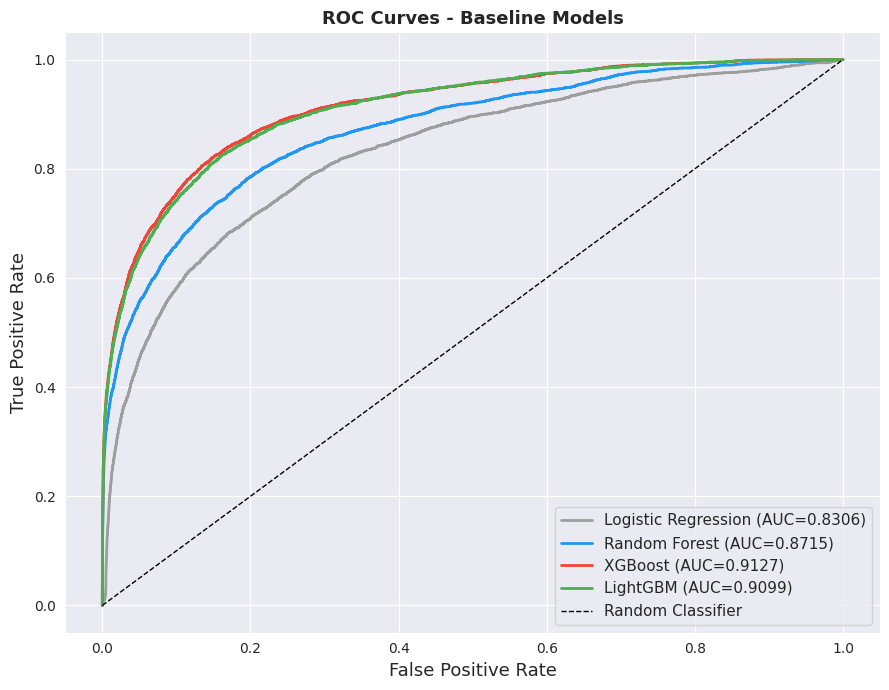

  Saved -> figures/11_roc_baselines.png


In [10]:
# ── Plot ROC curves for all 4 models on one chart ─────────────────────────────
plt.figure(figsize=(9, 7))
palette = ['#9E9E9E','#2196F3','#F44336','#4CAF50']

for (name, probs), color in zip([
    ('Logistic Regression', lr_probs),
    ('Random Forest',       rf_probs),
    ('XGBoost',             xgb_probs),
    ('LightGBM',            lgbm_probs),
], palette):
    # Compute ROC curve points
    fpr_c, tpr_c, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr_c, tpr_c, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

# Diagonal line = random classifier baseline
plt.plot([0,1],[0,1],'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Baseline Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
savefig('11_roc_baselines')

## 11. Precision-Recall Curves
More informative than ROC for imbalanced datasets. Shows Precision-Recall trade-off and threshold analysis for XGBoost.

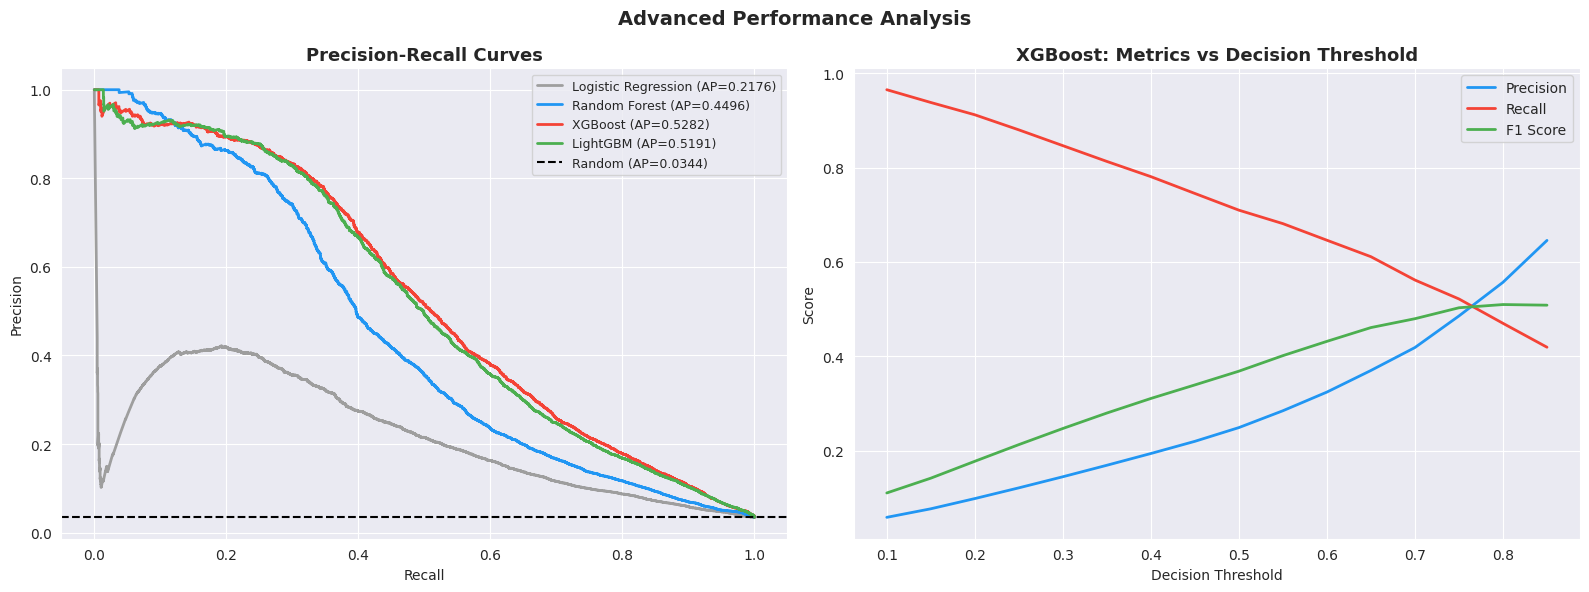

  Saved -> figures/12_precision_recall.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Precision-Recall curves for all models ────────────────────────────────────
for (name, probs), color in zip([
    ('Logistic Regression', lr_probs),
    ('Random Forest',       rf_probs),
    ('XGBoost',             xgb_probs),
    ('LightGBM',            lgbm_probs),
], palette):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)  # area under PR curve
    axes[0].plot(rec, prec, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)

# Random classifier baseline = fraud rate
axes[0].axhline(y_test.mean(), color='black', linestyle='--',
                label=f'Random (AP={y_test.mean():.4f})')
axes[0].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9)

# ── XGBoost threshold analysis ────────────────────────────────────────────────
# Shows how Precision/Recall/F1 change as we adjust the classification threshold
thresholds  = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

axes[1].plot(thresholds, precisions, color='#2196F3', linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls,    color='#F44336', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1s,        color='#4CAF50', linewidth=2, label='F1 Score')
axes[1].set_title('XGBoost: Metrics vs Decision Threshold', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.suptitle('Advanced Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('12_precision_recall')

## 12. Confusion Matrices
Shows exactly how many transactions were correctly and incorrectly classified. FP and FN are the most business-critical cells for fraud detection.

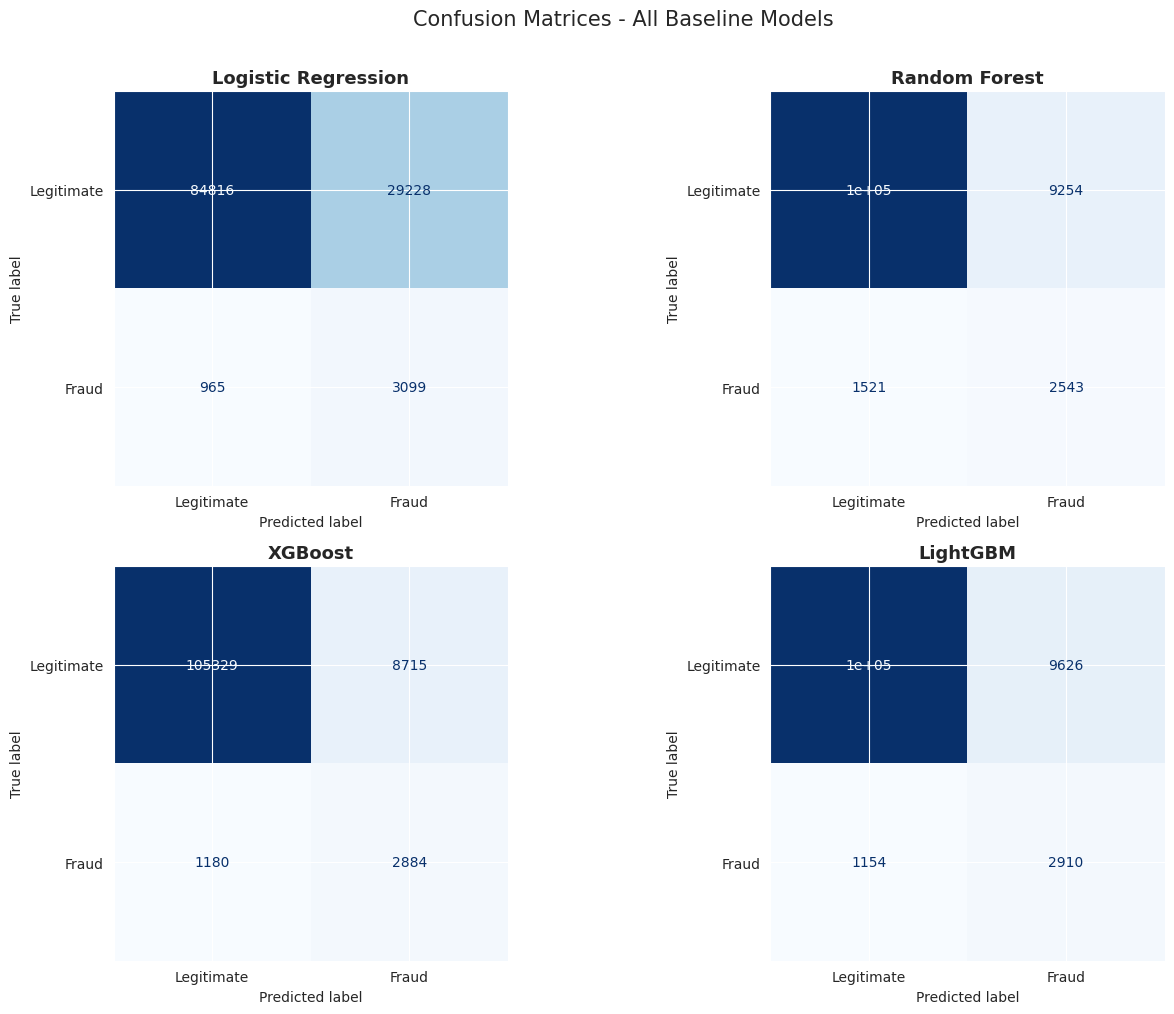

  Saved -> figures/13_confusion_matrices.png


In [12]:
# ── Plot 2x2 grid of confusion matrices ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    ('XGBoost',             xgb_preds),
    ('LightGBM',            lgbm_preds),
]):
    # TN=top-left, FP=top-right, FN=bottom-left, TP=bottom-right
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=['Legitimate','Fraud']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices - All Baseline Models', fontsize=15, y=1.01)
plt.tight_layout()
savefig('13_confusion_matrices')

## 13. Feature Importance Analysis
Three perspectives on XGBoost feature importance, plus comparison with Random Forest.

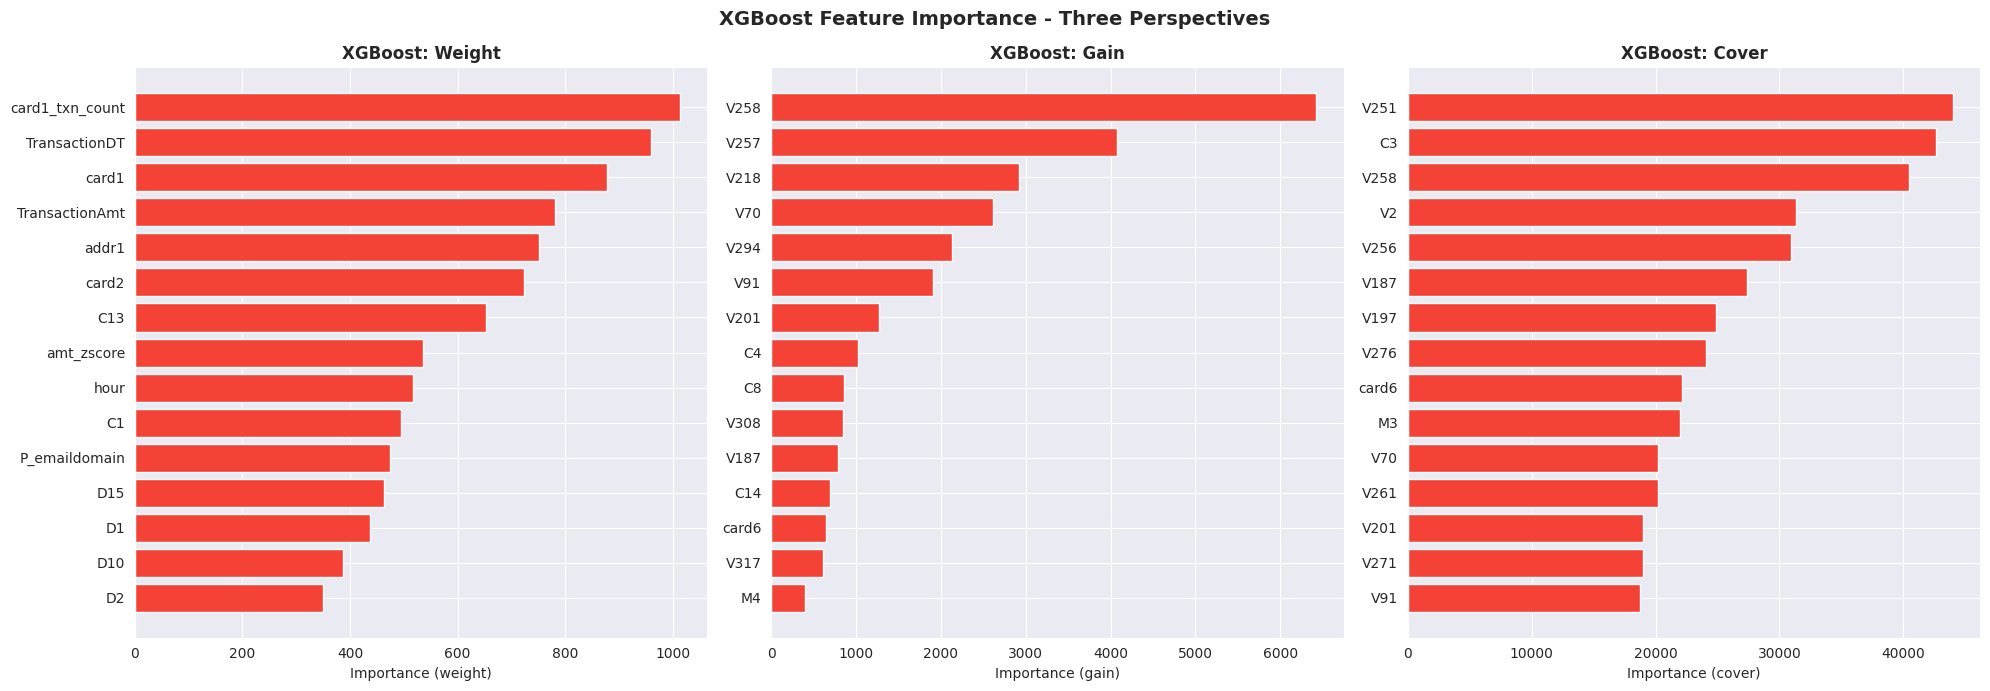

  Saved -> figures/14_xgb_importance_3methods.png


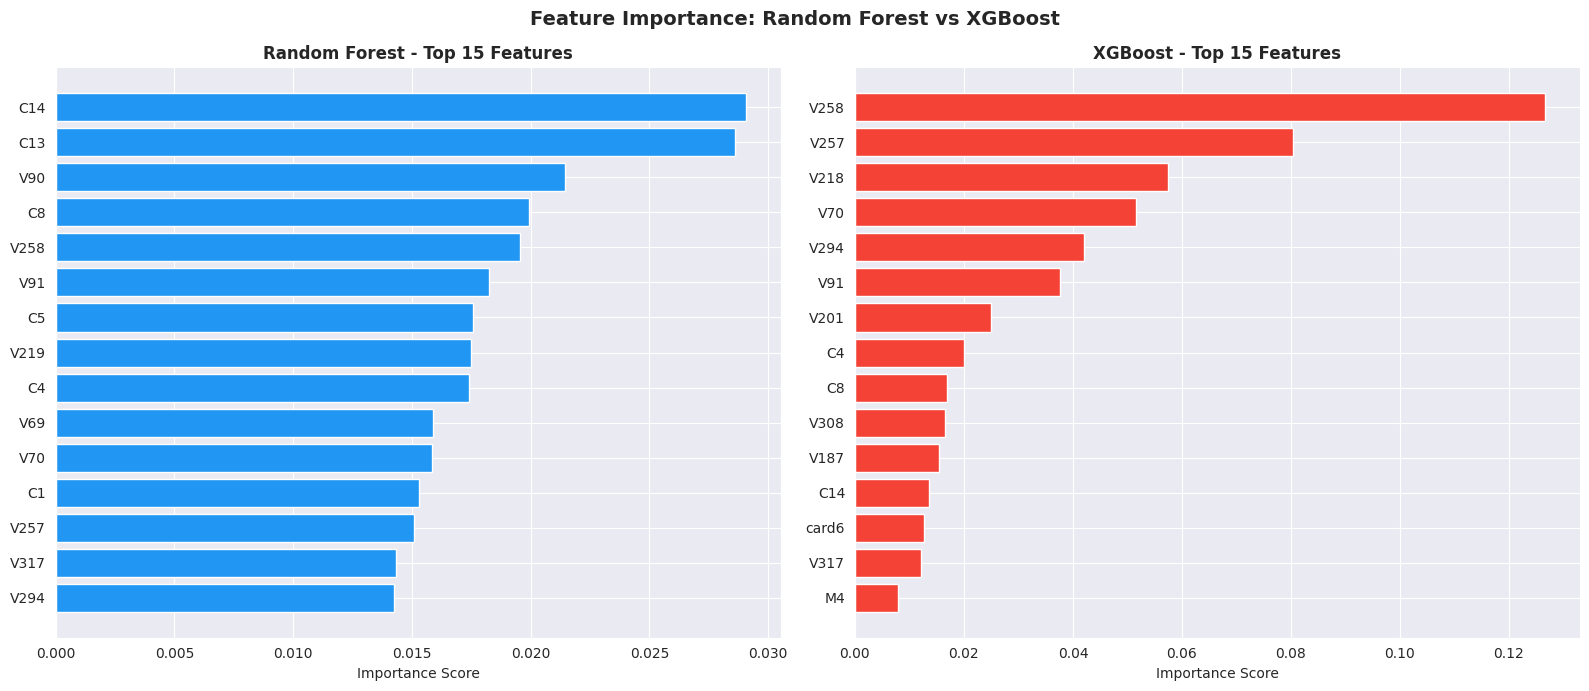

  Saved -> figures/15_rf_vs_xgb_importance.png


In [13]:
# ── XGBoost feature importance: 3 methods ────────────────────────────────────
# weight: how many times a feature is used to split
# gain:   average improvement in loss when feature is used (most meaningful)
# cover:  average number of samples affected by splits on this feature
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, importance_type in zip(axes, ['weight','gain','cover']):
    importance = pd.Series(
        xgb.get_booster().get_score(importance_type=importance_type)
    ).sort_values(ascending=False).head(15)
    ax.barh(importance.index[::-1], importance.values[::-1],
            color='#F44336', edgecolor='white')
    ax.set_title(f'XGBoost: {importance_type.capitalize()}', fontweight='bold')
    ax.set_xlabel(f'Importance ({importance_type})')

plt.suptitle('XGBoost Feature Importance - Three Perspectives',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('14_xgb_importance_3methods')

# ── Random Forest vs XGBoost feature importance comparison ───────────────────
rf_imp  = pd.Series(rf.feature_importances_,
                    index=X_train.columns).sort_values(ascending=False).head(15)
xgb_imp = pd.Series(xgb.feature_importances_,
                    index=X_train.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(rf_imp.index[::-1],  rf_imp.values[::-1],  color='#2196F3', edgecolor='white')
axes[0].set_title('Random Forest - Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Importance Score')

axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='#F44336', edgecolor='white')
axes[1].set_title('XGBoost - Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('15_rf_vs_xgb_importance')

## 14. Metrics Heatmap and FPR Comparison
Heatmap gives at-a-glance view of all models. FPR chart directly addresses the research question.

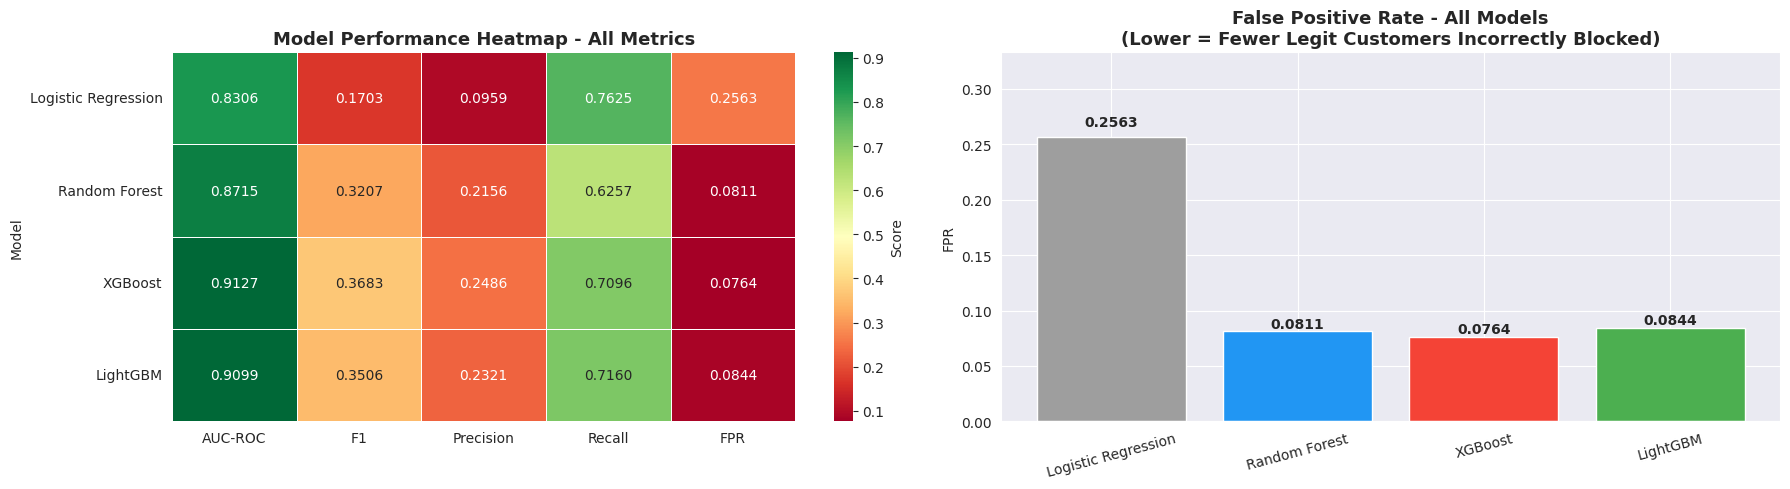

  Saved -> figures/16_heatmap_and_fpr.png
NOTEBOOK 02 COMPLETE
Next -> 03_GNN_GraphSAGE.ipynb


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Metrics heatmap ───────────────────────────────────────────────────────────
# Green = good performance, Red = poor performance
# Note: for FPR, lower is better (inverted colour scale)
metrics_data = results_df[['AUC-ROC','F1','Precision','Recall','FPR']]
sns.heatmap(
    metrics_data, annot=True, fmt='.4f',
    cmap='RdYlGn', linewidths=0.5, ax=axes[0],
    cbar_kws={'label': 'Score'}
)
axes[0].set_title('Model Performance Heatmap - All Metrics', fontweight='bold', fontsize=13)

# ── FPR comparison bar chart ──────────────────────────────────────────────────
# FPR = proportion of legitimate customers incorrectly blocked
# This directly answers our research question about reducing false positives
fpr_vals = results_df['FPR']
colors   = ['#9E9E9E','#2196F3','#F44336','#4CAF50']
bars     = axes[1].bar(fpr_vals.index, fpr_vals.values, color=colors, edgecolor='white')
for bar, val in zip(bars, fpr_vals.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.04,
                 f'{val:.4f}', ha='center', fontweight='bold')
axes[1].set_title('False Positive Rate - All Models\n'
                  '(Lower = Fewer Legit Customers Incorrectly Blocked)',
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel('FPR')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, max(fpr_vals.values)*1.3)

plt.tight_layout()
savefig('16_heatmap_and_fpr')

print('NOTEBOOK 02 COMPLETE')
print('Next -> 03_GNN_GraphSAGE.ipynb')

---
## Notebook Summary

| Model | AUC | Key Strength |
|---|---|---|
| Logistic Regression | ~0.83 | Simple linear baseline |
| Random Forest | ~0.87 | Non-linear ensemble |
| XGBoost | ~0.91 | Industry standard for tabular fraud |
| LightGBM | ~0.91 | Faster XGBoost — confirms result |

**Key finding:** 0.91 AUC is the ceiling for transaction-level fraud detection. To go higher, we need graph-based relational features — addressed in NB03.

**Next:** `03_GNN_GraphSAGE.ipynb`